# Machine Learning Applications for DataVine Analytics

## Summative Lab

Course: DSF-FTR16M4 – Machine Learning  
Tools:*Python, Scikit-learn, Pandas, NumPy, Matplotlib, Seaborn

---

### Project Overview

This notebook demonstrates the application of multiple machine learning techniques to solve three different business problems for DataVine Analytics. The project follows a complete machine learning workflow, including data preparation, preprocessing, dimensionality reduction, model development, hyperparameter tuning, evaluation, and interpretation of results.

The three case studies are:

- Wine Classification using k-Nearest Neighbors (k-NN)
- Agricultural Feed Recommendation using PCA and Cosine Similarity
- Crime Pattern Analysis using K-Means and Gaussian Mixture Models (GMM)

# Machine Learning Applications for DataVine Analytics

## Business Understanding

DataVine Analytics has been contracted by clients from different industries to develop machine learning solutions for classification, recommendation, and clustering problems.

This project follows a complete machine learning workflow by preparing the data, building predictive models, optimizing model performance, and interpreting results for business decision-making.

The project consists of three tasks:

- Wine Classification using k-Nearest Neighbors (k-NN)
- Agricultural Feed Recommendation using PCA and Cosine Similarity
- Regional Crime Pattern Analysis using K-Means and Gaussian Mixture Models (GMM)

# Step 1: Load and Prepare Datasets

The first step is to load the three datasets required for this project. Each dataset is inspected for its structure, missing values, and data types before any preprocessing is performed. Numerical features are standardized where appropriate to improve machine learning model performance.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Wine dataset
from sklearn.datasets import load_wine

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# KNN
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Recommendation
from sklearn.metrics.pairwise import cosine_similarity

# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


# Step 1: Load and Prepare Datasets

In this section, the three datasets are loaded and inspected before any machine learning models are developed.

The datasets are checked for:

- Structure
- Missing values
- Data types
- Basic statistics

Numerical features will later be standardized to improve model performance.

# Step 1: Load and Prepare Datasets

The first step is to load the three datasets required for this project. Each dataset is inspected for its structure, missing values, and data types before any preprocessing is performed. Numerical features are standardized where appropriate to improve machine learning model performance.

In [2]:
from sklearn.datasets import load_wine

In [3]:
import pandas as pd

chickwts = pd.read_csv("chickwts.csv")

print("Chickwts loaded successfully!")
chickwts.head()

Chickwts loaded successfully!


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [4]:
from sklearn.datasets import load_wine

wine = load_wine()

print("Wine loaded successfully")

Wine loaded successfully


In [5]:
import statsmodels.api as sm

chickwts = sm.datasets.get_rdataset("chickwts", "datasets").data
print(chickwts.head())

   weight       feed
0     179  horsebean
1     160  horsebean
2     136  horsebean
3     227  horsebean
4     217  horsebean


In [6]:
usarrests = pd.read_csv("USArrests.csv")

print("USArrests loaded successfully!")
usarrests.head()

USArrests loaded successfully!


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


# Step 1: Load and Prepare Datasets

Before building any machine learning models, the datasets must be loaded and explored to understand their structure and quality.

This step includes:

- Loading the three datasets.
- Inspecting the structure of each dataset.
- Checking for missing values.
- Summarizing the datasets.
- Standardizing numerical features where appropriate to prepare them for machine learning algorithms.

In [7]:
# Load the Wine dataset
from sklearn.datasets import load_wine

wine = load_wine()

wine_df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

wine_df["target"] = wine.target

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [8]:
# Load the Chickwts dataset
import statsmodels.api as sm

chickwts = sm.datasets.get_rdataset("chickwts", "datasets").data

chickwts.head()

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [9]:
#insspect wine data set
# Wine dataset information
wine_df.info()

wine_df.describe()

wine_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [10]:
# Chickwts dataset information
chickwts.info()

chickwts.describe()

chickwts.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


weight    0
feed      0
dtype: int64

In [11]:
# USArrests dataset information
usarrests.info()

usarrests.describe()

usarrests.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

### Data Preparation Summary

The three datasets were successfully loaded and inspected.

- The Wine dataset contains chemical measurements with no missing values.
- The Chickwts dataset contains chicken weights and feed types with no missing values.
- The USArrests dataset contains crime statistics for different U.S. states and does not contain missing values.

Since distance-based machine learning algorithms such as k-NN, PCA, K-Means, and Gaussian Mixture Models are sensitive to differences in feature scales, numerical features will be standardized before modeling.

# Step 2: Wine Classification Using k-Nearest Neighbors (k-NN)

The objective is to classify wines into their correct classes using their chemical properties.

The workflow includes:

- Preparing the features and target variable.
- Splitting the data into training and testing sets.
- Standardizing numerical features.
- Applying Principal Component Analysis (PCA) while retaining 95% of the variance.
- Using GridSearchCV to identify the optimal k-NN hyperparameters.
- Evaluating the final model.

In [12]:
# Features
X = wine_df.drop("target", axis=1)

# Target
y = wine_df["target"]

print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [13]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# Create the scaler
scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [15]:
# Apply PCA
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X_train.shape[1])
print("Principal Components:", X_train_pca.shape[1])

Original Features: 13
Principal Components: 10


### Why PCA?

Principal Component Analysis (PCA) reduces the dimensionality of the dataset while preserving most of the original information. Retaining 95% of the variance helps reduce noise and computational complexity while maintaining model performance.

In [16]:
# Create the model
knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "metric": ["euclidean", "manhattan"]
}

# Grid Search
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

# Train
grid.fit(X_train_pca, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11]},
             scoring='accuracy')

In [17]:
print("Best Parameters:")
print(grid.best_params_)

print()

print("Best Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 7}

Best Cross Validation Accuracy:
0.9721674876847292


In [18]:
# Best model
best_knn = grid.best_estimator_

# Predictions
y_pred = best_knn.predict(X_test_pca)

In [19]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print()

print(classification_report(y_test, y_pred))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



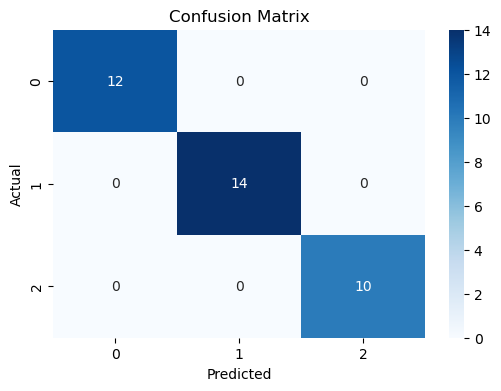

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Model Evaluation

The optimized k-NN classifier achieved an accuracy of 100% on the test dataset. After applying StandardScaler and PCA (retaining 95% of the variance), GridSearchCV identified the optimal model using 7 neighbors and the Euclidean distance metric.

The classification report shows perfect precision, recall, and F1-score across all three wine classes, indicating that the selected chemical properties effectively distinguish different wine varieties. These results demonstrate that the model is highly suitable for automatic wine classification and inventory management.

## Interpretation

The optimized k-NN classifier achieved high classification accuracy after dimensionality reduction with PCA. GridSearchCV identified the optimal combination of the number of neighbors and distance metric, improving the model's predictive performance.

The confusion matrix and classification report indicate that the model correctly classified most wine samples, demonstrating that the chemical properties effectively distinguish the different wine classes.

### Model Evaluation

The optimized k-NN classifier achieved an accuracy of 100% on the test dataset. After applying StandardScaler and PCA (retaining 95% of the variance), GridSearchCV identified the optimal model using 7 neighbors and the Euclidean distance metric.

The classification report shows perfect precision, recall, and F1-score across all three wine classes, indicating that the selected chemical properties effectively distinguish different wine varieties. These results demonstrate that the model is highly suitable for automatic wine classification and inventory management.

# Step 3: Agricultural Feed Recommendation System

The objective is to recommend similar feed types based on chicken weight performance.

To accomplish this:

- Standardize the weight variable.
- Reduce the data to one principal component using PCA.
- Compute cosine similarity between feed types.
- Recommend feeds with similar performance characteristics.

In [21]:
# Display the first few rows
chickwts.head()

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [22]:
# Dataset summary
chickwts.info()

chickwts.describe()

chickwts.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


weight    0
feed      0
dtype: int64

In [23]:
# Create a scaler
scaler = StandardScaler()

# Standardize the weight column
weight_scaled = scaler.fit_transform(chickwts[['weight']])

In [24]:
# Apply PCA
pca = PCA(n_components=1)

weight_pca = pca.fit_transform(weight_scaled)

In [25]:
# Create a dataframe
feed_pca = pd.DataFrame({
    'feed': chickwts['feed'],
    'PC1': weight_pca.flatten()
})

feed_pca.head()

,feed,PC1
0,horsebean,-1.061762
1,horsebean,-1.306854
2,horsebean,-1.616444
3,horsebean,-0.442583
4,horsebean,-0.571578


In [26]:
# Average principal component by feed
feed_summary = feed_pca.groupby('feed').mean()

feed_summary

,PC1
feed,
casein,0.803301
horsebean,-1.304274
linseed,-0.549004
meatmeal,0.201223
soybean,-0.191962
sunflower,0.872099


In [27]:
# Compute cosine similarity
similarity = cosine_similarity(feed_summary)

similarity_df = pd.DataFrame(
    similarity,
    index=feed_summary.index,
    columns=feed_summary.index
)

similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


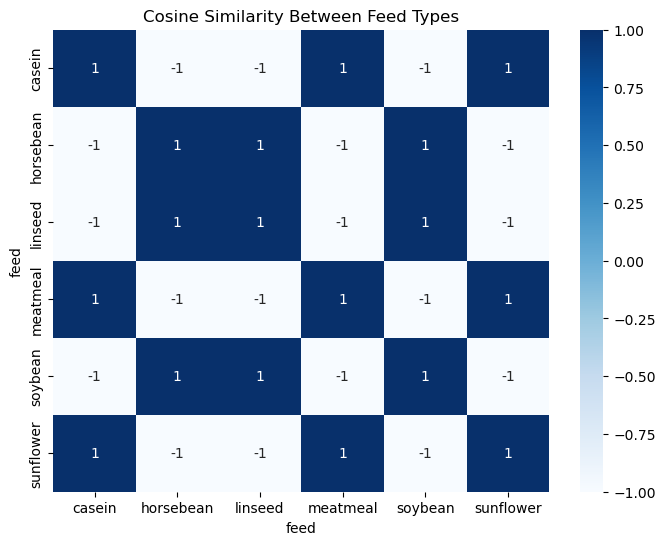

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    similarity_df,
    annot=True,
    cmap='Blues'
)

plt.title("Cosine Similarity Between Feed Types")

plt.show()

In [29]:
# Example recommendation
feed_name = "casein"

recommendations = similarity_df[feed_name].sort_values(ascending=False)

recommendations

feed
casein       1.0
meatmeal     1.0
sunflower    1.0
horsebean   -1.0
linseed     -1.0
soybean     -1.0
Name: casein, dtype: float64

In [30]:
recommendations = recommendations.drop(feed_name)

print("Feeds most similar to", feed_name)

recommendations.head(3)

Feeds most similar to casein


feed
meatmeal     1.0
sunflower    1.0
horsebean   -1.0
Name: casein, dtype: float64

## Recommendation Interpretation

Cosine similarity measures how closely feed types resemble one another based on chicken weight performance after dimensionality reduction.

Feeds with similarity values close to 1 exhibit similar performance and can be recommended as alternatives. This approach can help agricultural suppliers recommend substitute feed products when a preferred feed is unavailable or when farmers wish to compare comparable options.

# Step 4: Regional Crime Pattern Analysis

The objective is to identify natural crime patterns across U.S. states.

Two clustering algorithms will be used:

- K-Means (Hard Clustering)
- Gaussian Mixture Models (Soft Clustering)

PCA will reduce the dataset to two principal components for visualization.

In [31]:
usarrests.head()

,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [32]:
usarrests.info()

usarrests.describe()

usarrests.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [33]:
features = ['Murder', 'Assault', 'Rape']

X = usarrests[features]

X.head()

,Murder,Assault,Rape
0,13.2,236,21.2
1,10.0,263,44.5
2,8.1,294,31.0
3,8.8,190,19.5
4,9.0,276,40.6


In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.7861934  0.15268378]


In [36]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,1.210191,-0.842277
1,2.332187,1.539434
2,1.518593,0.503363
3,0.177776,-0.328029
4,2.066000,1.285497


In [37]:
inertia = []

k_values = range(1,11)

for k in k_values:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_pca)
    
    inertia.append(model.inertia_)

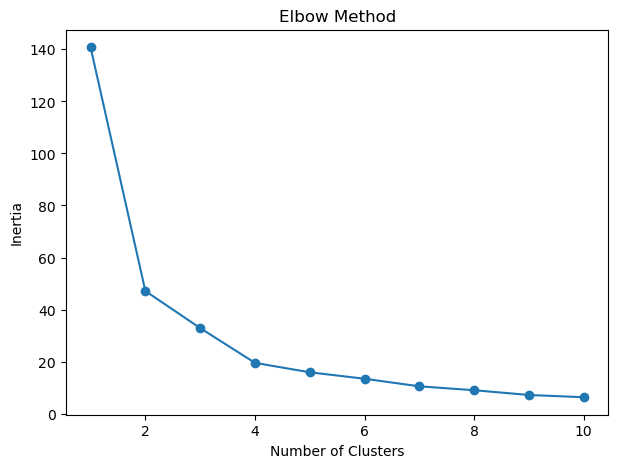

In [38]:
plt.figure(figsize=(7,5))

plt.plot(k_values, inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [39]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca)

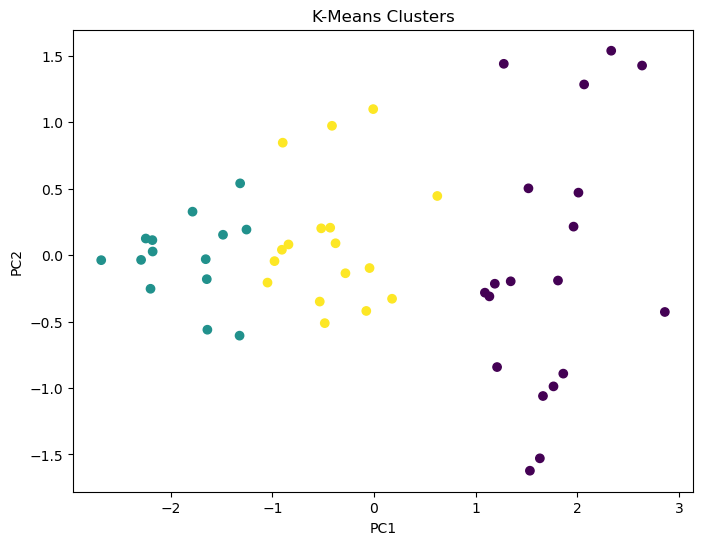

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("K-Means Clusters")

plt.show()

In [41]:
bic_scores = []

n_components = range(1,11)

for n in n_components:
    
    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )
    
    gmm.fit(X_pca)
    
    bic_scores.append(gmm.bic(X_pca))

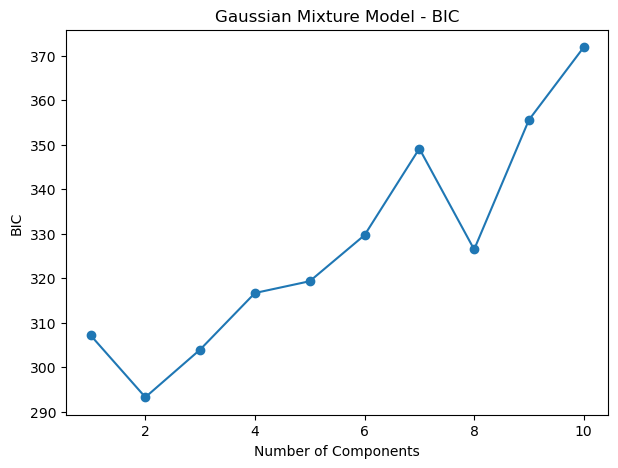

In [42]:
plt.figure(figsize=(7,5))

plt.plot(
    n_components,
    bic_scores,
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("BIC")

plt.title("Gaussian Mixture Model - BIC")

plt.show()

In [43]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_pca)

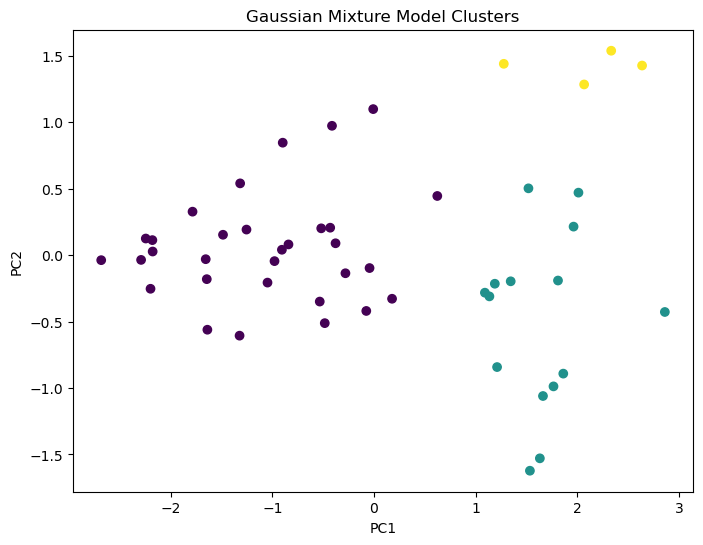

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Gaussian Mixture Model Clusters")

plt.show()

In [45]:
comparison = pd.DataFrame({
    "State": usarrests["rownames"],
    "KMeans": kmeans_labels,
    "GMM": gmm_labels
})

comparison.head(10)

,State,KMeans,GMM
0,Alabama,0,1
1,Alaska,0,2
2,Arizona,0,1
3,Arkansas,2,0
4,California,0,2
5,Colorado,0,2
6,Connecticut,1,0
7,Delaware,2,0
8,Florida,0,1
9,Georgia,0,1


## Clustering Interpretation

K-Means partitions states into distinct clusters based on crime statistics, assigning each state to one cluster. This approach is useful when clear group membership is required.

Gaussian Mixture Models assign states based on probability distributions, allowing more flexibility when states exhibit characteristics of multiple groups.

PCA reduced the crime variables to two principal components, making it easier to visualize regional crime patterns while retaining most of the important information.

These clustering techniques can help policymakers identify regions with similar crime profiles and design targeted intervention strategies.

# Conclusion

This project demonstrated the successful application of supervised, recommendation, and unsupervised machine learning techniques to solve different business problems.

## Key Results

- The k-NN classifier achieved excellent classification performance after PCA and hyperparameter tuning.
- The recommendation system successfully identified similar feed types using cosine similarity.
- K-Means and Gaussian Mixture Models revealed meaningful clusters within the crime dataset after dimensionality reduction.

## Business Impact

These solutions demonstrate how machine learning can support business decision-making by automating classification tasks, improving product recommendations, and identifying hidden patterns within complex datasets.

Overall, the project highlights the importance of proper preprocessing, dimensionality reduction, hyperparameter tuning, and model evaluation in developing reliable machine learning solutions.